**Лабораторна робота №6**

Встановлення та імпорт бібліотек

In [1]:
!pip install kaggle
!pip install scikit-learn pandas numpy matplotlib seaborn torch nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
import nltk
from nltk.tokenize import word_tokenize
import re
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

Завантажуємо необхідні дані NLTK

In [7]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Встановлюємо seed для відтворюваності

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Використовується пристрій: {device}")

Використовується пристрій: cpu


Завантажуємо дані

In [4]:
try:
    fake_df = pd.read_csv('Fake.csv')
    true_df = pd.read_csv('True.csv')

    # Додаємо мітки
    fake_df['label'] = 1  # Фейкові новини
    true_df['label'] = 0  # Справжні новини

    # Об'єднуємо датасети
    df = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)

    # Перемішуємо дані
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    print(f"Загальна кількість статей: {len(df)}")
    print(f"Фейкових новин: {len(fake_df)}")
    print(f"Справжніх новин: {len(true_df)}")
    print(f"\nПерші рядки датасету:")
    print(df.head())
    print(f"\nРозподіл міток:\n{df['label'].value_counts()}")

except FileNotFoundError:
    print("ПОМИЛКА: Файли Fake.csv та True.csv не знайдені!")
    print("Завантажте їх з Kaggle: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset")

Загальна кількість статей: 44898
Фейкових новин: 23481
Справжніх новин: 21417

Перші рядки датасету:
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      1  
1       April 5, 2017       0  
2  September 27, 2017       0  
3         May

Попередня обробка тексту

In [5]:
def clean_text(text):
    """Очищує текст від зайвих символів"""
    if pd.isna(text):
        return ""
    # Переводимо в нижній регістр
    text = text.lower()
    # Видаляємо URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Видаляємо email
    text = re.sub(r'\S+@\S+', '', text)
    # Залишаємо тільки букви та пробіли
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Видаляємо зайві пробіли
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Створюємо колонку з комбінацією заголовка та тексту
df['combined_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Очищуємо текст
print("Очищення тексту...")
df['cleaned_text'] = df['combined_text'].apply(clean_text)

# Видаляємо порожні рядки
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

print(f"Кількість статей після очищення: {len(df)}")
print(f"\nПриклад очищеного тексту:")
print(df['cleaned_text'].iloc[0][:200])

Очищення тексту...
Кількість статей після очищення: 44889

Приклад очищеного тексту:
ben stein calls out th circuit court committed a coup dtat against the constitution st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing 


Токенізація та створення словника

In [8]:
print("Токенізація текстів...")
df['tokens'] = df['cleaned_text'].apply(word_tokenize)

# Створюємо словник з найчастіших слів
MAX_VOCAB_SIZE = 20000
all_tokens = [token for tokens in df['tokens'] for token in tokens]
token_counts = Counter(all_tokens)
most_common = token_counts.most_common(MAX_VOCAB_SIZE - 2)  # -2 для PAD та UNK

# Створюємо словник: слово -> індекс
word2idx = {'<PAD>': 0, '<UNK>': 1}
word2idx.update({word: idx + 2 for idx, (word, _) in enumerate(most_common)})

idx2word = {idx: word for word, idx in word2idx.items()}

vocab_size = len(word2idx)
print(f"Розмір словника: {vocab_size}")
print(f"Найчастіші слова: {most_common[:10]}")

Токенізація текстів...
Розмір словника: 20000
Найчастіші слова: [('the', 1016905), ('to', 552134), ('of', 448946), ('a', 412698), ('and', 410501), ('in', 354567), ('that', 238221), ('on', 196629), ('for', 179345), ('s', 176566)]


Конвертація токенів в індекси та padding

In [9]:
MAX_LENGTH = 500  # Максимальна довжина послідовності

def tokens_to_indices(tokens, word2idx, max_length):
    """Конвертує токени в індекси з padding"""
    indices = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]
    # Обрізаємо або доповнюємо до max_length
    if len(indices) > max_length:
        indices = indices[:max_length]
    else:
        indices = indices + [word2idx['<PAD>']] * (max_length - len(indices))
    return indices

print("Конвертація токенів в індекси...")
df['indices'] = df['tokens'].apply(lambda x: tokens_to_indices(x, word2idx, MAX_LENGTH))

print(f"Приклад індексів (перші 20): {df['indices'].iloc[0][:20]}")

Конвертація токенів в індекси...
Приклад індексів (перші 20): [1714, 3177, 575, 57, 701, 2373, 132, 1074, 5, 1966, 1, 89, 2, 967, 579, 759, 611, 148, 1714, 3177]


Розділення на train/val/test

In [11]:
# Спочатку розділяємо на train+val (90%) та test (10%)
X = np.array(df['indices'].tolist())
y = df['label'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=SEED, stratify=y
)

# Потім train+val розділяємо на train (80% від усього) та val (10% від усього)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=SEED, stratify=y_temp  # 0.111 * 0.9 ≈ 0.1
)

print(f"Розмір train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Розмір val: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Розмір test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nРозподіл міток у train: {np.bincount(y_train)}")
print(f"Розподіл міток у val: {np.bincount(y_val)}")
print(f"Розподіл міток у test: {np.bincount(y_test)}")

Розмір train: 35915 (80.0%)
Розмір val: 4485 (10.0%)
Розмір test: 4489 (10.0%)

Розподіл міток у train: [17135 18780]
Розподіл міток у val: [2140 2345]
Розподіл міток у test: [2142 2347]


Створення Dataset та DataLoader

In [12]:
class NewsDataset(Dataset):
    """PyTorch Dataset для новин"""
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Створюємо datasets
train_dataset = NewsDataset(X_train, y_train)
val_dataset = NewsDataset(X_val, y_val)
test_dataset = NewsDataset(X_test, y_test)

# Створюємо dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Кількість батчів у train: {len(train_loader)}")
print(f"Кількість батчів у val: {len(val_loader)}")
print(f"Кількість батчів у test: {len(test_loader)}")

Кількість батчів у train: 562
Кількість батчів у val: 71
Кількість батчів у test: 71


Визначення моделі Simple RNN

In [13]:
class SimpleRNNClassifier(nn.Module):
    """Проста RNN для бінарної класифікації"""
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.2):
        super(SimpleRNNClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=(dropout if num_layers > 1 else 0.0)
        )

        self.fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch_size, seq_length)
        emb = self.embedding(x)  # (batch_size, seq_length, emb_dim)
        emb = self.dropout(emb)

        out, h_n = self.rnn(emb)  # h_n: (num_layers, batch_size, hidden_dim)

        # Беремо останній hidden state
        last_hidden = h_n[-1]  # (batch_size, hidden_dim)
        last_hidden = self.dropout(last_hidden)

        logits = self.fc(last_hidden).squeeze(1)  # (batch_size,)
        probs = torch.sigmoid(logits)

        return probs, logits

Визначення моделі LSTM

In [14]:
class LSTMClassifier(nn.Module):
    """LSTM для бінарної класифікації"""
    def __init__(self, vocab_size, emb_dim, hidden_dim,
                 num_layers=1, bidirectional=False, dropout=0.2):
        super(LSTMClassifier, self).__init__()

        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=(dropout if num_layers > 1 else 0.0)
        )

        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * factor, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch_size, seq_length)
        emb = self.embedding(x)  # (batch_size, seq_length, emb_dim)
        emb = self.dropout(emb)

        out, (h_n, c_n) = self.lstm(emb)
        # h_n: (num_layers * num_directions, batch_size, hidden_dim)

        if self.bidirectional:
            # Конкатенуємо forward і backward останні hidden states
            last_hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            last_hidden = h_n[-1]

        last_hidden = self.dropout(last_hidden)

        logits = self.fc(last_hidden).squeeze(1)  # (batch_size,)
        probs = torch.sigmoid(logits)

        return probs, logits

Функція для тренування

In [15]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Тренування однієї епохи"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        probs, logits = model(x_batch)

        loss = criterion(logits, y_batch)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item()
        all_preds.extend((probs > 0.5).cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy

Функція для оцінки

In [16]:
def evaluate(model, dataloader, criterion, device):
    """Оцінка моделі"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            probs, logits = model(x_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item()
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs > 0.5).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    # Обчислюємо метрики
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall': recall_score(all_labels, all_preds, zero_division=0),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
        'roc_auc': roc_auc_score(all_labels, all_probs)
    }

    return metrics, all_probs, all_preds, all_labels

Функція для повного тренування моделі

In [17]:
def train_model(model, train_loader, val_loader, num_epochs, lr, device):
    """Повне тренування моделі з валідацією"""
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }

    best_val_f1 = 0
    best_model_state = None

    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()

        # Тренування
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # Валідація
        val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)

        # Зберігаємо історію
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])

        # Зберігаємо найкращу модель
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_model_state = model.state_dict().copy()

        epoch_time = time.time() - epoch_start

        print(f"Epoch {epoch+1}/{num_epochs} ({epoch_time:.2f}s) - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, "
              f"Val F1: {val_metrics['f1']:.4f}")

    total_time = time.time() - start_time

    # Завантажуємо найкращу модель
    model.load_state_dict(best_model_state)

    return model, history, total_time

Функція для візуалізації історії тренувань

In [18]:
def plot_training_history(history, title):
    """Візуалізація процесу тренування"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy and F1
    axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
    axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s')
    axes[1].plot(history['val_f1'], label='Val F1-Score', marker='^')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].set_title(f'{title} - Metrics')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

Функція для візуалізації confusion matrix

In [19]:
def plot_confusion_matrix(y_true, y_pred, title):
    """Візуалізація матриці помилок"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title(f'{title} - Confusion Matrix')
    plt.show()

    return cm

Функція для візуалізації ROC кривої

In [20]:
def plot_roc_curve(y_true, y_probs, title):
    """Візуалізація ROC кривої"""
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = roc_auc_score(y_true, y_probs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title} - ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

Тренування Simple RNN

*Задаємо гіперпараметри*

In [21]:
EMB_DIM = 100
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.2
LR = 0.001
NUM_EPOCHS = 10

*Створюємо модель*

In [22]:
rnn_model = SimpleRNNClassifier(
    vocab_size=vocab_size,
    emb_dim=EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

print(f"\nМодель RNN:")
print(rnn_model)
print(f"\nКількість параметрів: {sum(p.numel() for p in rnn_model.parameters()):,}")


Модель RNN:
SimpleRNNClassifier(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (rnn): RNN(100, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

Кількість параметрів: 2,062,593


*Тренуємо модель*

In [23]:
rnn_model, rnn_history, rnn_time = train_model(
    rnn_model, train_loader, val_loader, NUM_EPOCHS, LR, device
)

print(f"\nЗагальний час тренування RNN: {rnn_time:.2f}s ({rnn_time/NUM_EPOCHS:.2f}s/epoch)")

Epoch 1/10 (1579.39s) - Train Loss: 0.6908, Train Acc: 0.5276, Val Loss: 0.6850, Val Acc: 0.5449, Val F1: 0.6744
Epoch 2/10 (1457.41s) - Train Loss: 0.6885, Train Acc: 0.5292, Val Loss: 0.6948, Val Acc: 0.5061, Val F1: 0.5074
Epoch 3/10 (1634.81s) - Train Loss: 0.6940, Train Acc: 0.5169, Val Loss: 0.6933, Val Acc: 0.5115, Val F1: 0.5217
Epoch 4/10 (1219.95s) - Train Loss: 0.6640, Train Acc: 0.5911, Val Loss: 0.5953, Val Acc: 0.7166, Val F1: 0.7006
Epoch 5/10 (1031.49s) - Train Loss: 0.5105, Train Acc: 0.7903, Val Loss: 0.4669, Val Acc: 0.8276, Val F1: 0.8415
Epoch 6/10 (977.06s) - Train Loss: 0.4622, Train Acc: 0.8210, Val Loss: 0.5900, Val Acc: 0.7213, Val F1: 0.6811
Epoch 7/10 (967.13s) - Train Loss: 0.4688, Train Acc: 0.8083, Val Loss: 0.4746, Val Acc: 0.7984, Val F1: 0.7776
Epoch 8/10 (912.94s) - Train Loss: 0.4142, Train Acc: 0.8508, Val Loss: 0.3927, Val Acc: 0.8557, Val F1: 0.8514
Epoch 9/10 (1047.17s) - Train Loss: 0.4764, Train Acc: 0.8074, Val Loss: 0.5754, Val Acc: 0.7173, V

Оцінка Simple RNN на тестовому наборі

In [24]:
criterion = nn.BCEWithLogitsLoss()
rnn_test_metrics, rnn_test_probs, rnn_test_preds, rnn_test_labels = evaluate(
    rnn_model, test_loader, criterion, device
)

print("\nМетрики Simple RNN на тестовому наборі:")
print(f"Accuracy:  {rnn_test_metrics['accuracy']:.4f}")
print(f"Precision: {rnn_test_metrics['precision']:.4f}")
print(f"Recall:    {rnn_test_metrics['recall']:.4f}")
print(f"F1-Score:  {rnn_test_metrics['f1']:.4f}")
print(f"ROC AUC:   {rnn_test_metrics['roc_auc']:.4f}")


Метрики Simple RNN на тестовому наборі:
Accuracy:  0.7955
Precision: 0.7760
Recall:    0.8560
F1-Score:  0.8140
ROC AUC:   0.8064


Візуалізація результатів Simple RNN

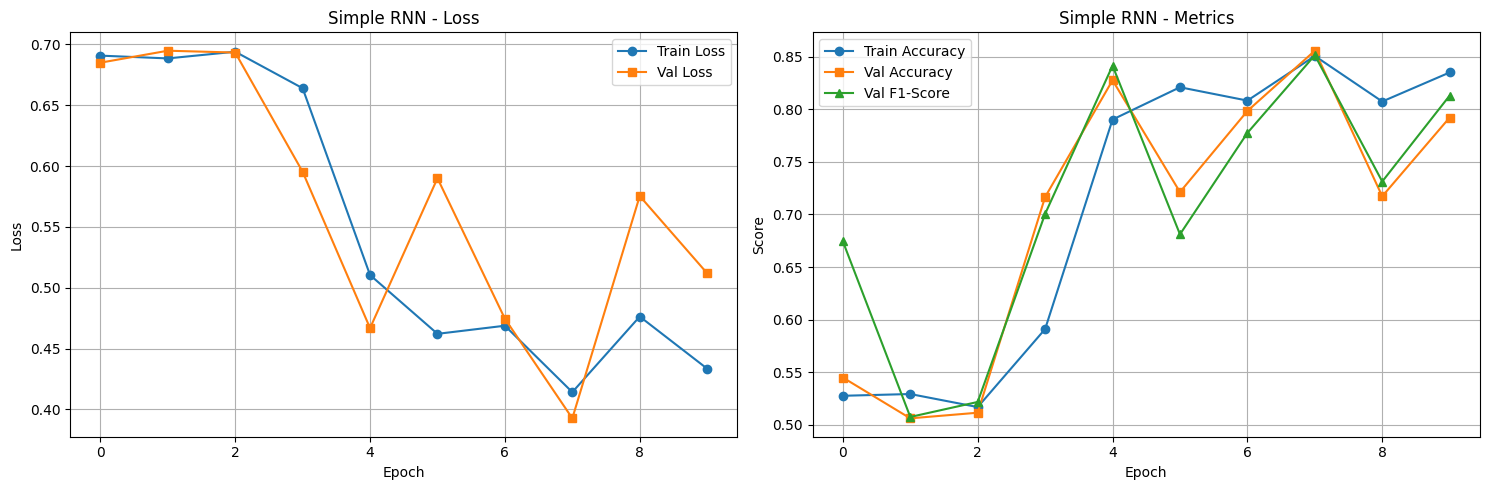

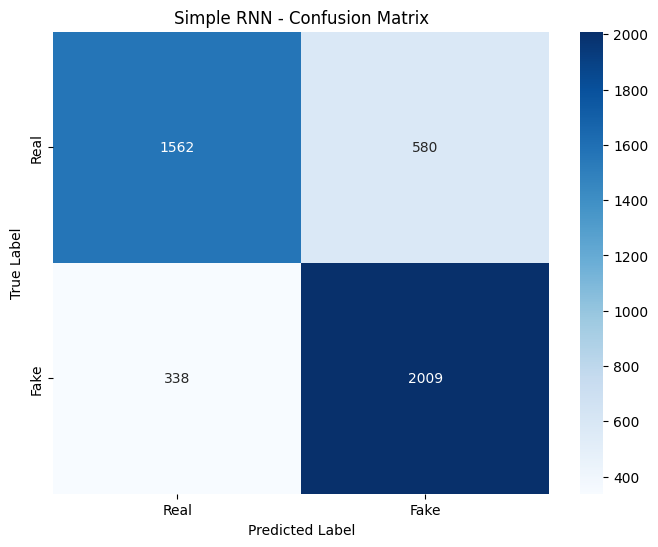

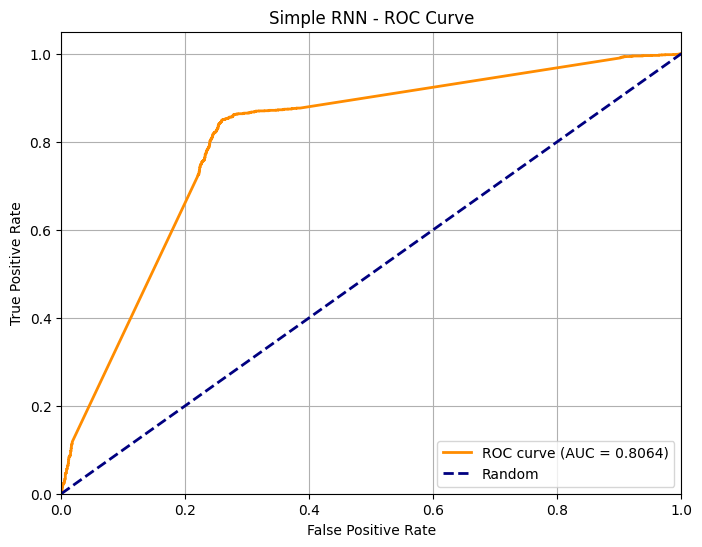

In [25]:
# Графіки тренування
plot_training_history(rnn_history, "Simple RNN")

# Confusion Matrix
rnn_cm = plot_confusion_matrix(rnn_test_labels, rnn_test_preds, "Simple RNN")

# ROC Curve
plot_roc_curve(rnn_test_labels, rnn_test_probs, "Simple RNN")

Тренування LSTM

*Задаємо значення гіперпараметрів*

In [26]:
EMB_DIM = 100
HIDDEN_DIM = 128
NUM_LAYERS = 2
BIDIRECTIONAL = False
DROPOUT = 0.2
LR = 0.001
NUM_EPOCHS = 10

*Створюємо модель*

In [27]:
lstm_model = LSTMClassifier(
    vocab_size=vocab_size,
    emb_dim=EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    bidirectional=BIDIRECTIONAL,
    dropout=DROPOUT
)

print(f"\nМодель LSTM:")
print(lstm_model)
print(f"\nКількість параметрів: {sum(p.numel() for p in lstm_model.parameters()):,}")


Модель LSTM:
LSTMClassifier(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

Кількість параметрів: 2,249,985


*Тренуємо модель*

In [28]:
lstm_model, lstm_history, lstm_time = train_model(
    lstm_model, train_loader, val_loader, NUM_EPOCHS, LR, device
)

print(f"\nЗагальний час тренування LSTM: {lstm_time:.2f}s ({lstm_time/NUM_EPOCHS:.2f}s/epoch)")

Epoch 1/10 (3648.91s) - Train Loss: 0.6611, Train Acc: 0.5863, Val Loss: 0.6796, Val Acc: 0.5487, Val F1: 0.6975
Epoch 2/10 (3050.40s) - Train Loss: 0.5408, Train Acc: 0.6782, Val Loss: 0.1564, Val Acc: 0.9541, Val F1: 0.9554
Epoch 3/10 (1170.75s) - Train Loss: 0.1182, Train Acc: 0.9683, Val Loss: 0.0479, Val Acc: 0.9860, Val F1: 0.9866
Epoch 4/10 (1225.34s) - Train Loss: 0.0325, Train Acc: 0.9928, Val Loss: 0.0198, Val Acc: 0.9960, Val F1: 0.9962
Epoch 5/10 (1837.88s) - Train Loss: 0.0174, Train Acc: 0.9965, Val Loss: 0.0165, Val Acc: 0.9967, Val F1: 0.9968
Epoch 6/10 (1548.10s) - Train Loss: 0.0130, Train Acc: 0.9975, Val Loss: 0.0166, Val Acc: 0.9973, Val F1: 0.9974
Epoch 7/10 (1180.94s) - Train Loss: 0.0134, Train Acc: 0.9975, Val Loss: 0.0104, Val Acc: 0.9978, Val F1: 0.9979
Epoch 8/10 (1137.62s) - Train Loss: 0.0119, Train Acc: 0.9978, Val Loss: 0.0104, Val Acc: 0.9982, Val F1: 0.9983
Epoch 9/10 (1559.95s) - Train Loss: 0.0100, Train Acc: 0.9981, Val Loss: 0.0126, Val Acc: 0.9964

Оцінка LSTM на тестовому наборі

In [29]:
lstm_test_metrics, lstm_test_probs, lstm_test_preds, lstm_test_labels = evaluate(
    lstm_model, test_loader, criterion, device
)

print("\nМетрики LSTM на тестовому наборі:")
print(f"Accuracy:  {lstm_test_metrics['accuracy']:.4f}")
print(f"Precision: {lstm_test_metrics['precision']:.4f}")
print(f"Recall:    {lstm_test_metrics['recall']:.4f}")
print(f"F1-Score:  {lstm_test_metrics['f1']:.4f}")
print(f"ROC AUC:   {lstm_test_metrics['roc_auc']:.4f}")


Метрики LSTM на тестовому наборі:
Accuracy:  0.9980
Precision: 0.9962
Recall:    1.0000
F1-Score:  0.9981
ROC AUC:   0.9982


Візуалізація результатів LSTM

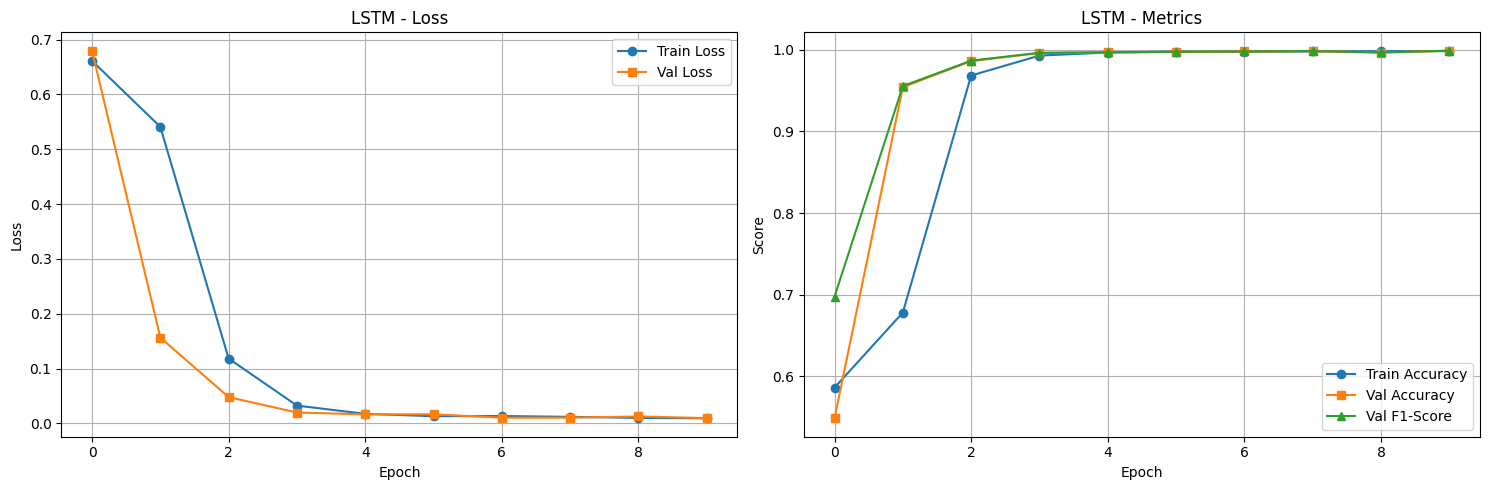

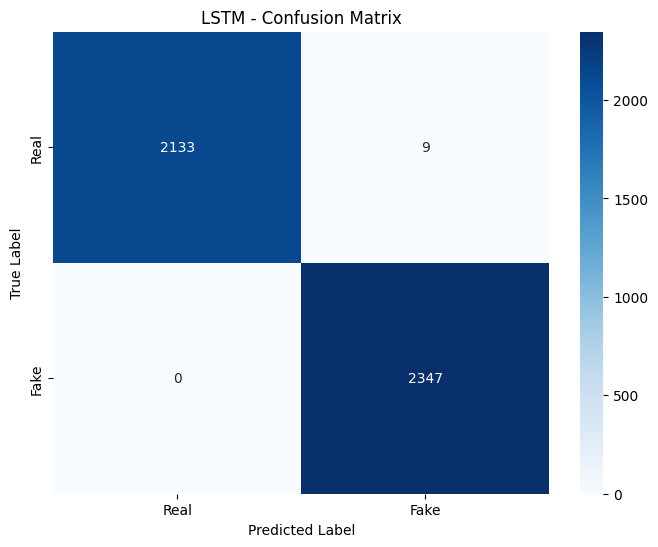

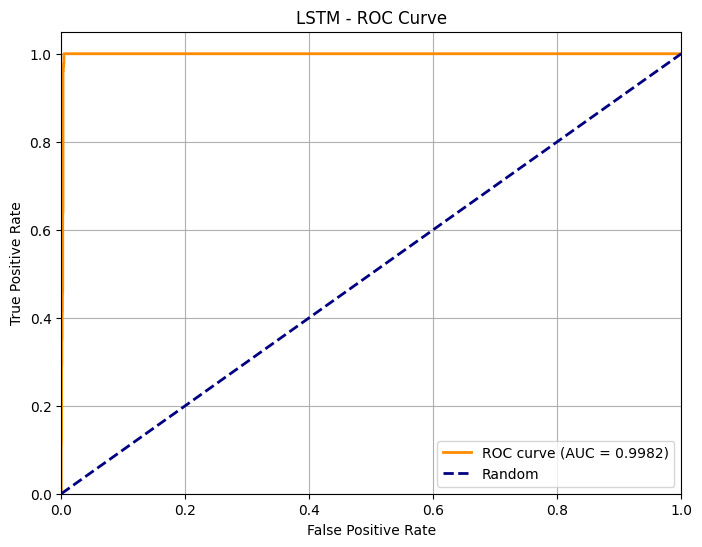

In [30]:
# Графіки тренування
plot_training_history(lstm_history, "LSTM")

# Confusion Matrix
lstm_cm = plot_confusion_matrix(lstm_test_labels, lstm_test_preds, "LSTM")

# ROC Curve
plot_roc_curve(lstm_test_labels, lstm_test_probs, "LSTM")

Порівняння RNN vs LSTM

In [31]:
# Таблиця порівняння метрик
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC', 'Train Time (s)'],
    'Simple RNN': [
        rnn_test_metrics['accuracy'],
        rnn_test_metrics['precision'],
        rnn_test_metrics['recall'],
        rnn_test_metrics['f1'],
        rnn_test_metrics['roc_auc'],
        rnn_time
    ],
    'LSTM': [
        lstm_test_metrics['accuracy'],
        lstm_test_metrics['precision'],
        lstm_test_metrics['recall'],
        lstm_test_metrics['f1'],
        lstm_test_metrics['roc_auc'],
        lstm_time
    ]
})

print("\n", comparison_df.to_string(index=False))


         Metric   Simple RNN         LSTM
      Accuracy     0.795500     0.997995
     Precision     0.775975     0.996180
        Recall     0.855986     1.000000
      F1-Score     0.814019     0.998086
       ROC AUC     0.806360     0.998209
Train Time (s) 12097.207037 17490.928167


Візуалізація порівняння

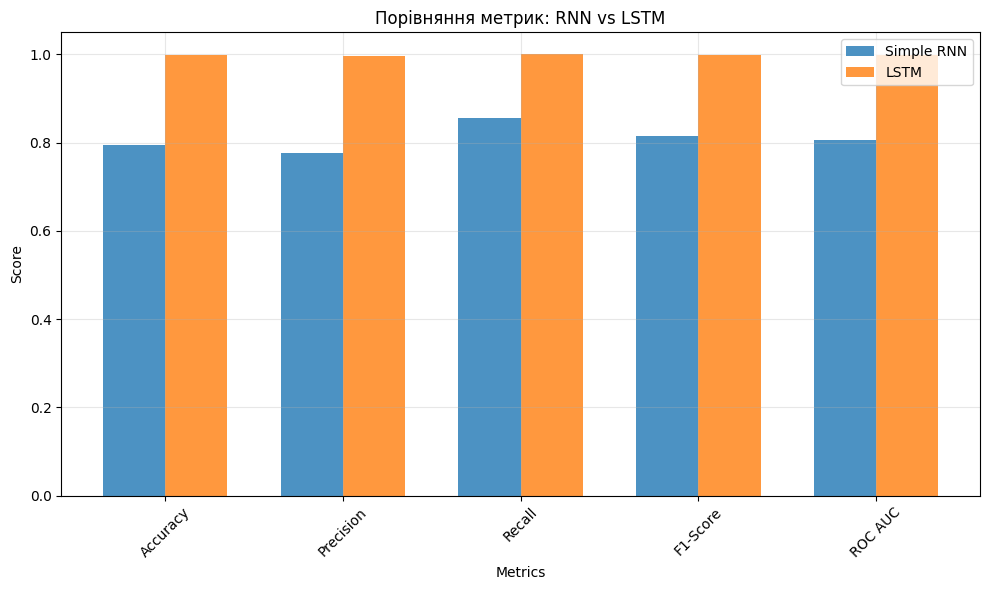

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

rnn_values = comparison_df[comparison_df['Metric'].isin(metrics_to_plot)]['Simple RNN'].values
lstm_values = comparison_df[comparison_df['Metric'].isin(metrics_to_plot)]['LSTM'].values

ax.bar(x - width/2, rnn_values, width, label='Simple RNN', alpha=0.8)
ax.bar(x + width/2, lstm_values, width, label='LSTM', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Порівняння метрик: RNN vs LSTM')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()